In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

print(df.head())

print(df.shape)

print(df.info())

   match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
0   1894783          1                      39                       17   
1   1741000          1                      31                       15   
2  30579330          0                      37                       24   
3  38972692          0                      21                       19   
4  38763513          1                      30                       29   

   team0_team_total_networth  team0_team_total_damage  \
0                     126186                    80559   
1                     108154                    66354   
2                     101614                    71195   
3                      95882                    46252   
4                     106544                    75778   

   team0_team_total_objectivedamage  team0_team_avg_level  \
0                             38477             18.333333   
1                             22284             17.333333   
2                      

# Inspecting Missing Values and Data/Features Distributions

In [3]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [4]:
print(df["team0_won"].value_counts())

print(df["team0_won"].value_counts(normalize=True))

team0_won
1    9156
0    9031
Name: count, dtype: int64
team0_won
1    0.503437
0    0.496563
Name: proportion, dtype: float64


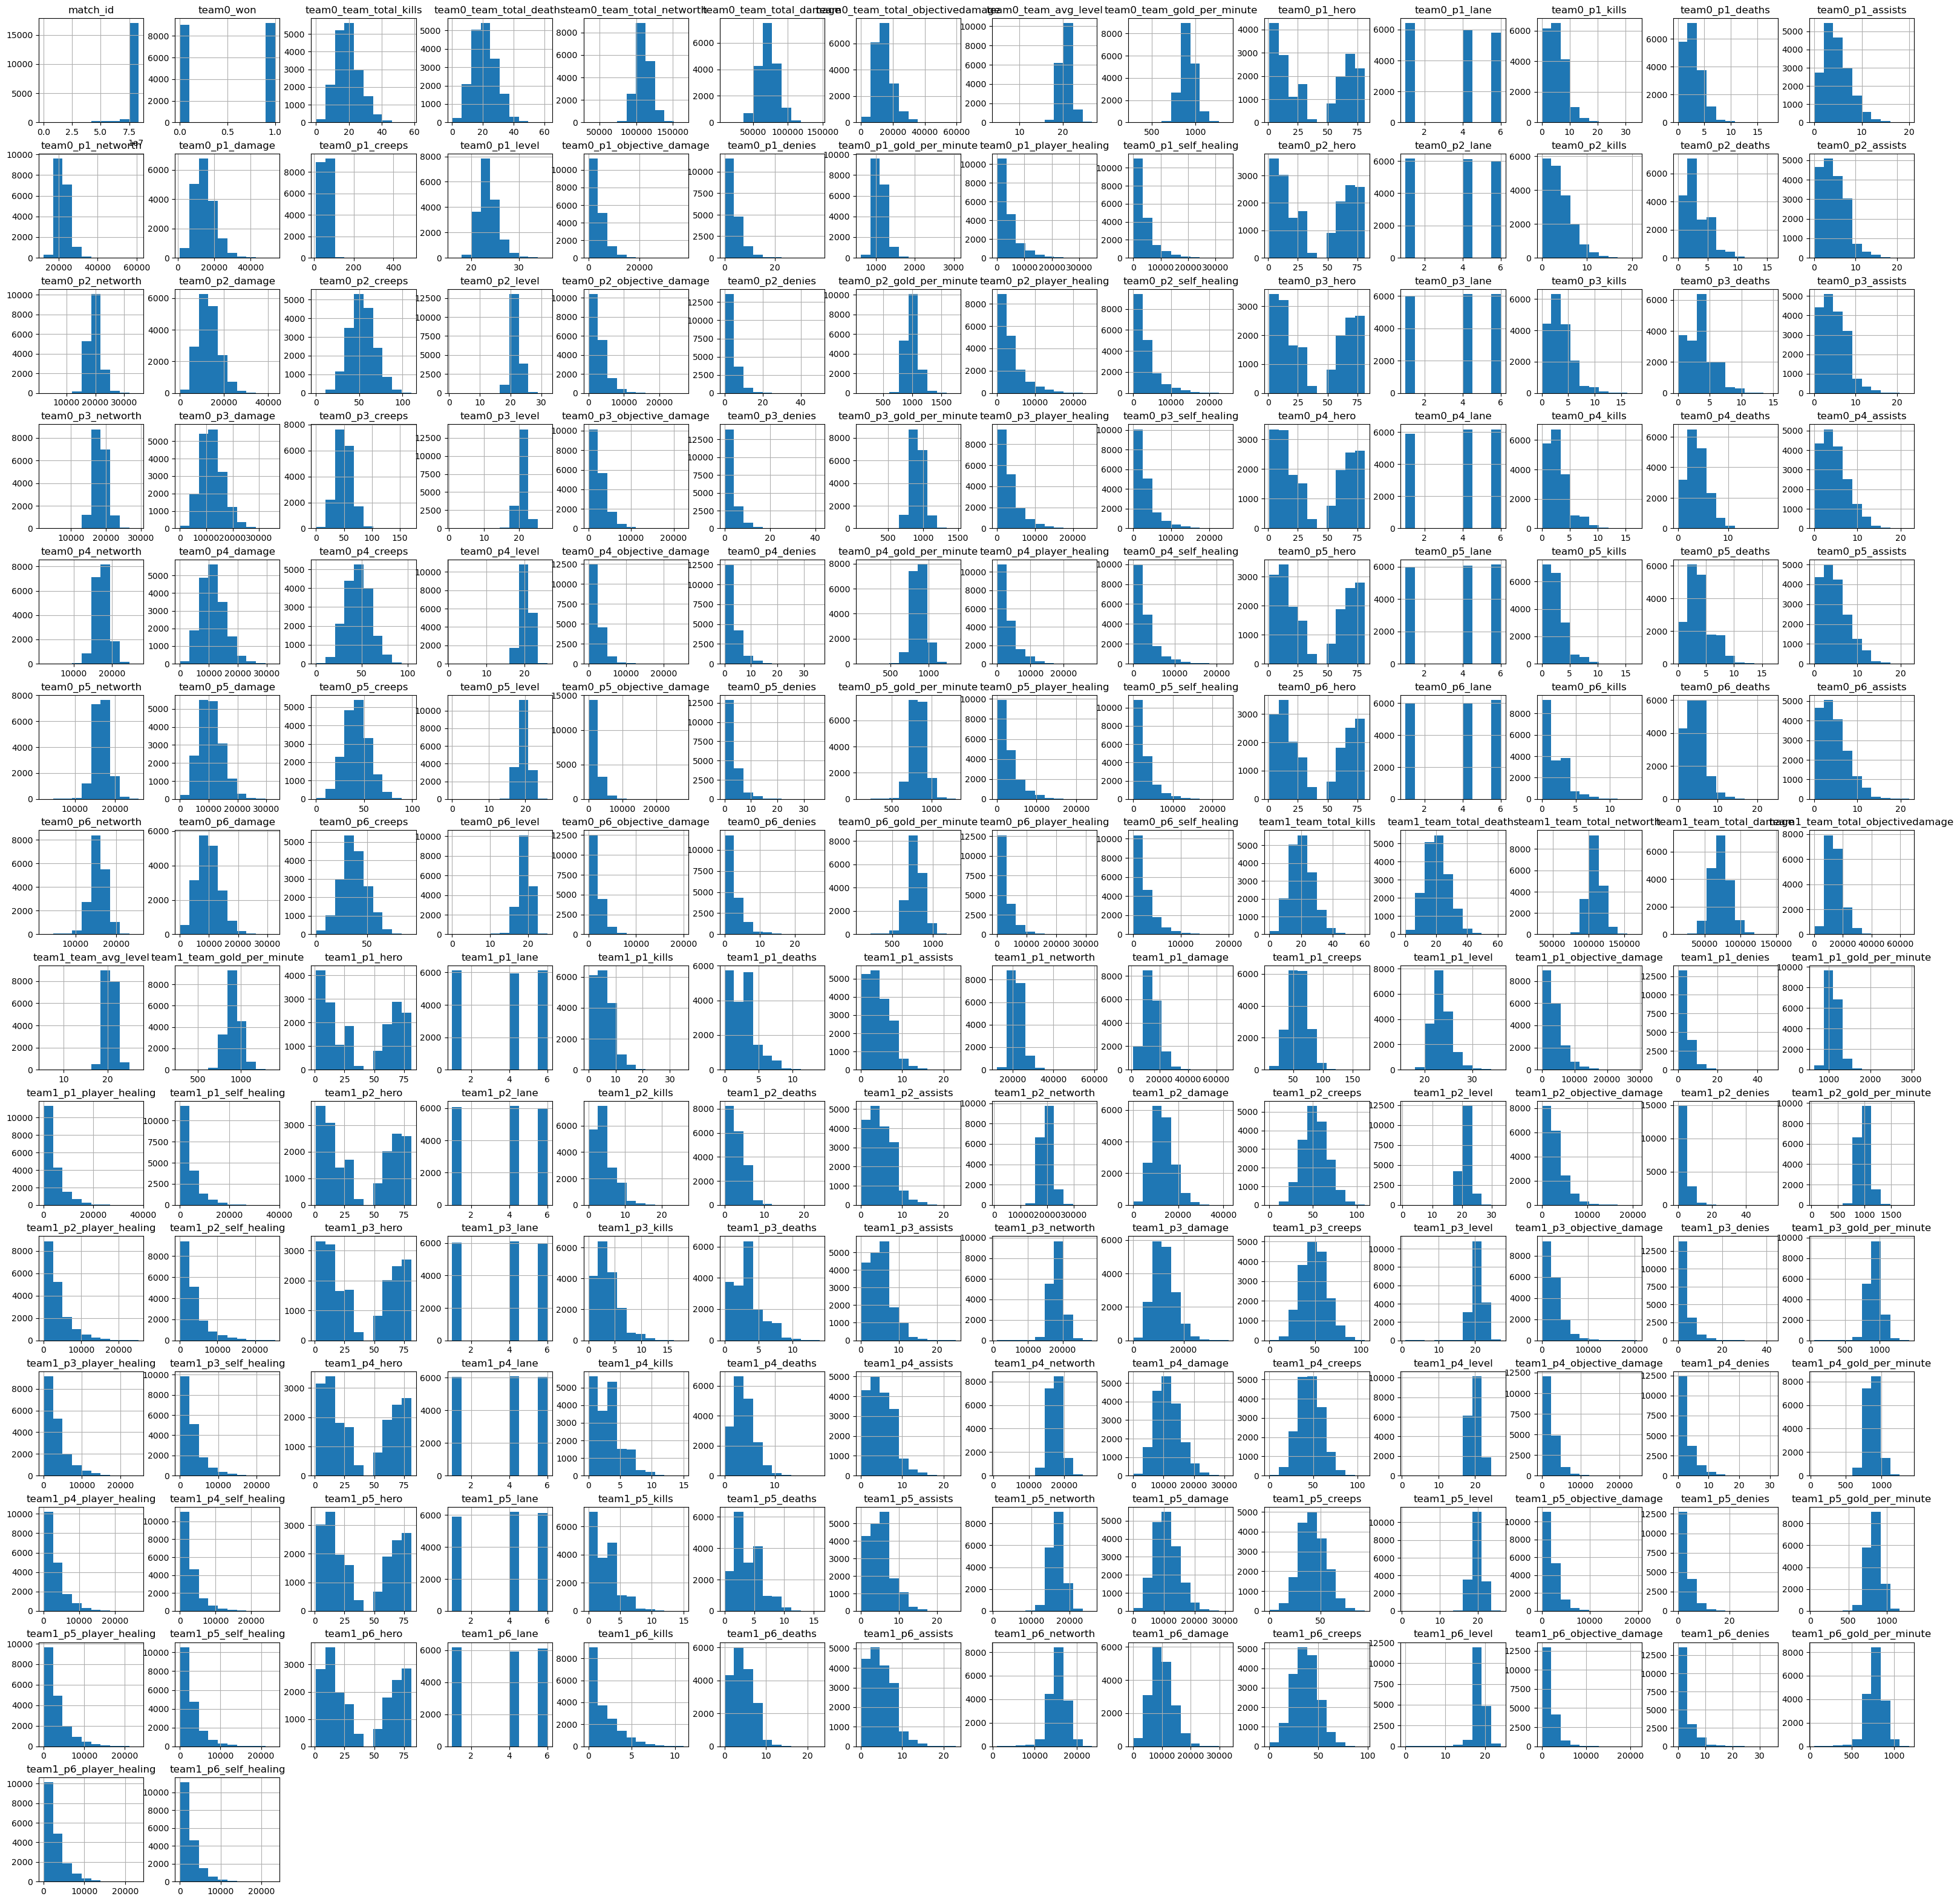

In [5]:
df.hist(figsize=(40, 40))

plt.show()

# Removing Outliers

count     18187.000000
mean     109694.522021
std       10369.255221
min       34329.000000
25%      102876.000000
50%      109123.000000
75%      115952.000000
max      164627.000000
Name: team0_team_total_networth, dtype: float64


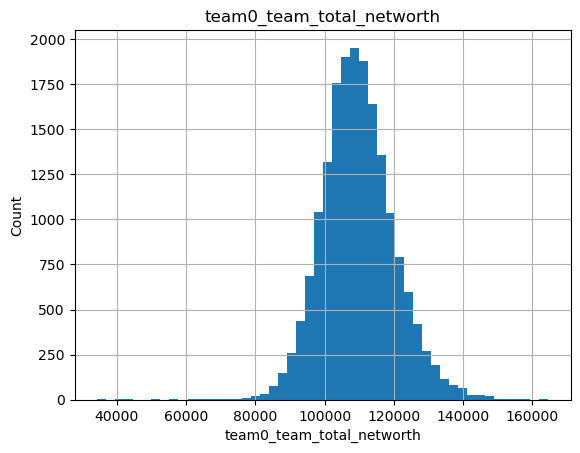

In [6]:
feature = "team0_team_total_networth"

print(df[feature].describe())

df[feature].hist(bins=50)

plt.title(feature)

plt.xlabel(feature)

plt.ylabel("Count")

plt.show()

In [7]:
threshold = 60000

count = (df["team0_team_total_networth"] < threshold).sum()

print(count)

outliers = df[df["team0_team_total_networth"] < 60000]

print((outliers.head(20)))

5
       match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
365    54195208          0                       0                       18   
2549   80881803          0                      10                        2   
7585   82619103          0                       2                        3   
13728  82959638          1                       3                        3   
17372  83239773          0                       6                        5   

       team0_team_total_networth  team0_team_total_damage  \
365                        55411                    12725   
2549                       40414                    26242   
7585                       34329                     9179   
13728                      51894                    17671   
17372                      42527                    19682   

       team0_team_total_objectivedamage  team0_team_avg_level  \
365                               11430             10.000000   
2549                      

# Inspecting Correlations

In [8]:
corr = df.corr(numeric_only=True)

print(corr["team0_won"].sort_values(ascending=False))

team0_won                           1.000000
team0_team_gold_per_minute          0.351066
team0_team_total_networth           0.351009
team0_team_total_kills              0.335300
team0_team_total_objectivedamage    0.329063
                                      ...   
team1_team_total_objectivedamage   -0.308966
team0_team_total_deaths            -0.323261
team1_team_total_networth          -0.326867
team1_team_gold_per_minute         -0.326978
team1_team_total_kills             -0.329733
Name: team0_won, Length: 184, dtype: float64
